# Amazon Reviews Analysis — Part 2: Learning Tasks

Continuation of Part 1, using the [Amazon Reviews 2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023)
dataset. This notebook applies machine-learning methods to the data:

1. **Clustering** — group products of each of the five categories by description, price and rating (TF-IDF + K-Means).
2. **Recommendation system** — user-based and item-based collaborative filtering, content-based filtering
   (pre-trained word embeddings) and a weighted hybrid.
3. **Classification** — predict review sentiment (positive / neutral / negative) from the review text.

Task 1 uses the product metadata of **all five categories** prepared in Part 1.
Tasks 2 and 3 use the **Baby Products** category only.

**How to run.** Developed on Google Colab. The data-preparation cells stream data from Hugging Face and are slow,
so they are run once and cached as CSVs on Google Drive (see *Load the cached CSVs*).

In [ ]:
!pip install datasets matplotlib seaborn gensim --upgrade
import os
import itertools
from itertools import islice
import re
import ast
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
import numpy as np

from datasets import load_dataset   # load_dataset function from Hugging Face.

import seaborn as sns               # Used for ploting.

In [ ]:
import spacy                       # Used for preprocessing.
nlp = spacy.load("en_core_web_sm")

from nltk.sentiment.vader import SentimentIntensityAnalyzer  # Used for sentiment analysis.
import nltk
nltk.download('vader_lexicon')

import gensim.downloader as api     # Used in Word2Vec vectors.
w2v_model = api.load("glove-wiki-gigaword-100")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer  # Used for bigrams.

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score

## Data loading and preprocessing

Helpers reused from Part 1, adapted for the Baby Products category.

In [ ]:
# Fields a record must contain (non-empty) to be kept.
requiredFields = ["rating", "title", "text", "asin", "parent_asin", "user_id", "timestamp"]      # reviews
requiredFields_metadata = ["main_category", "price", "average_rating",
                           "description", "parent_asin", "title"]                                  # metadata

##Functions for Data Parsing

In [ ]:
def is_valid_price(val):
    """True if `val` can be read as a non-negative price."""
    try:
        return val is not None and val != "" and float(val) >= 0
    except (TypeError, ValueError):
        return False


def is_valid_rating(val):
    """True if `val` can be read as a rating between 0 and 5."""
    try:
        return val is not None and val != "" and 0 <= float(val) <= 5
    except (TypeError, ValueError):
        return False


def clean_text(text):
    """Lower-case, strip non-letters, remove stop words and lemmatise with spaCy."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[^a-zA-Z]", " ", text.lower())
    doc = nlp(text)
    words = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(words)


def flatten_description(x):
    """Join a list of description fragments into a single string ('' for anything else)."""
    if isinstance(x, list):
        return " ".join(str(d) for d in x)
    elif isinstance(x, str):
        return x
    return ""


def create_csv(df, category, rows):
    """Save `df` to `<category>.csv` (spaces replaced by underscores)."""
    category = category.replace(" ", "_")
    filename = f"{category}.csv"
    df.to_csv(filename, index=False)
    print(f"Created {filename} with {rows} rows.")


def filter_by_review_frequency(df, min_reviews_per_user=5, min_reviews_per_item=5):
    """Iteratively drop users and items with too few reviews (a "k-core" filter).

    Removing sparse users can push items below the threshold (and vice versa), so the filter
    is repeated until the DataFrame stops shrinking. This keeps the user-item matrix dense
    enough for collaborative filtering.
    """
    prev_shape = (0, 0)
    curr_shape = df.shape

    while prev_shape != curr_shape:
        prev_shape = curr_shape

        item_counts = df["parent_asin"].value_counts()
        valid_items = item_counts[item_counts >= min_reviews_per_item].index

        user_counts = df["user_id"].value_counts()
        valid_users = user_counts[user_counts >= min_reviews_per_user].index

        df = df[df["user_id"].isin(valid_users) & df["parent_asin"].isin(valid_items)]
        curr_shape = df.shape

    return df


def select_entries(dataset, rows=1000):
    """Stream the reviews `dataset`, keep up to `rows` complete reviews, then clean and k-core filter them.

    Returns the filtered DataFrame and its length.
    """
    selected = []
    for entry in dataset:
        if all(field in entry and entry[field] for field in requiredFields):
            selected.append(entry)
            if len(selected) >= rows:
                break

    df = pd.DataFrame(selected)
    df = filter_by_review_frequency(df, 5, 5)             # Filter before the (slow) text cleaning.

    df["text"] = df["text"].apply(clean_text)
    df["title"] = df["title"].apply(clean_text)
    df = df[df["text"].notna() & (df["text"] != "")]
    df = df[df["title"].notna() & (df["title"] != "")]

    df = filter_by_review_frequency(df, 5, 5)             # Cleaning may have removed rows: filter again.

    print(f"Rows selected: {len(df)}")
    return df, len(df)


def select_entries_metadata(dataset, rows=1000):
    """Stream the metadata `dataset` and return up to `rows` cleaned products plus their count.

    Only products with a valid price and average rating are kept. A 20% buffer is collected
    up front because some titles/descriptions become empty after cleaning. Prices are min-max
    normalised into `norm_price`.
    """
    selected = []
    for entry in dataset:
        if all(field in entry and entry[field] for field in requiredFields_metadata):
            if is_valid_price(entry["price"]) and is_valid_rating(entry["average_rating"]):
                selected.append(entry)
                if len(selected) >= rows * 1.2:
                    break

    df = pd.DataFrame(selected)
    df["description"] = df["description"].apply(flatten_description)
    df["description"] = df["description"].apply(clean_text)
    df = df[df["description"].notna() & (df["description"] != "")]

    df["title"] = df["title"].apply(clean_text)
    df = df[df["title"].notna() & (df["title"] != "")]

    scaler = MinMaxScaler()
    df["norm_price"] = scaler.fit_transform(df[["price"]])

    print(f"Rows selected: {len(df)}")
    df = df.head(rows)
    return df, len(df)

### Build the Baby Products CSVs (run once)

Reviews: the first 45,000 complete reviews are streamed and then reduced by the 5-core filter
(every remaining user and item has at least 5 reviews), which leaves 2,818 reviews.
Metadata: 3,000 cleaned products.

In [ ]:
# Reviews

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Baby_Products",
                       split="full", streaming=True, trust_remote_code=True)

df, rows = select_entries(dataset, 45000)
create_csv(df, "Baby Products", rows)

reviews_data = pd.read_csv("Baby_Products.csv")

Rows selected: 2818
Created Baby_Products.csv with 2818 rows.


In [ ]:
# Product metadata.

meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Baby_Products", split="full", streaming=True, trust_remote_code=True)

features = meta_dataset.features.copy()
features.pop('image_url', None)               # Remove 'image_url' from the features (issue causing).
meta_dataset = meta_dataset.map(lambda x: x, features=features, remove_columns=['image_url'])

df, rows = select_entries_metadata(meta_dataset, 3000)
create_csv(df, "Baby Products Metadata", rows)

metadata_data = pd.read_csv("Baby_Products_Metadata.csv")

Rows selected: 3145
Created Baby_Products_Metadata.csv with 3000 rows.


### Load the cached CSVs

Set the two folders below to where the CSVs are stored on Google Drive:

* `DATA_DIR` — the Baby Products CSVs created above.
* `PART1_DATA_DIR` — the five-category metadata CSVs created in Part 1 (used by Task 1).

In [ ]:
# Get the .csv from drive (Don't have to parse every time).

from google.colab import drive
drive.mount('/content/drive')

csv_folder = "/content/drive/MyDrive/tede_csv_part2/"


# Read the .csv once and save it.
reviews_data = pd.read_csv(csv_folder + "Baby_Products.csv")            # 2818 review rows.
metadata_data = pd.read_csv(csv_folder + "Baby_Products_Metadata.csv")  # 3000 items rows.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Sentiment scores and ratings

Same combined score as in Part 1: `0.35 * VADER compound + 0.65 * normalised rating`.
(VADER is applied to the already-cleaned text, so negation words such as "not" are no longer present.)

In [ ]:
vader = SentimentIntensityAnalyzer()    # Initialize the sentiment analyzer.

def get_vader_sentiment(text):    # Return the compound sentiment score from VADER's polarity_scores method.
  return vader.polarity_scores(text)['compound']  # (-1, 1)

def normalize_rating(rating):    # Return the normalized rating.
    return (rating - 1) / 4

def final_sentiment_score(vader_score, norm_rating, w1 = 0.35 , w2 = 0.65):  # Return the combined sentiment score.
    return (w1 * vader_score + w2 * norm_rating)

df = reviews_data
df['text'] = df['text'].fillna('').str.strip()

df['sentiment_score'] = df['text'].apply(get_vader_sentiment)             # Calculate the sentiment score for each review.
df['norm_rating'] = df['rating'].apply(normalize_rating)                  # Normalize ratings.
df['final_sentiment_score'] = df.apply(lambda row: final_sentiment_score  # Calculate the final sentiment score.
  (row['sentiment_score'], row['norm_rating']), axis=1)

print(df[["text", "rating", "sentiment_score", "norm_rating", "final_sentiment_score"]].head(5))

print("\nStats for vader sentiment:\n")
print(df[["sentiment_score", "norm_rating", "final_sentiment_score"]].describe())

                                                text  rating  sentiment_score  \
0  huggie diaper child small grandchild soft non ...     5.0           0.8883   
1  ok diaper usually use pamper pinch huggie wasn...     3.0           0.9601   
2  love pamper grandson pamper exclusively bear b...     5.0           0.9709   
3  tell pamper exclusively child grandchild love ...     5.0           0.9729   
4  love large economical size pamper swaddler gre...     5.0           0.9313   

   norm_rating  final_sentiment_score  
0          1.0               0.960905  
1          0.5               0.661035  
2          1.0               0.989815  
3          1.0               0.990515  
4          1.0               0.975955  

Stats for vader sentiment:

       sentiment_score  norm_rating  final_sentiment_score
count      2818.000000  2818.000000            2818.000000
mean          0.672561     0.869056               0.800283
std           0.373690     0.237620               0.230517
min     

## Normalised ratings

Products are ranked by `average_rating * log(1 + review_count)`, so well-rated products with more reviews rank higher.

In [ ]:
df = reviews_data

grouped = df.groupby("parent_asin").agg(           # Group by parent_asin and calculate
        review_count=("rating", "count"),          # the number of ratings and the average rating.
        average_rating=("rating", "mean")
    ).reset_index()

grouped["weighted_rating"] = grouped["average_rating"] * np.log1p(grouped["review_count"])   # Calculate using the formula.
weighted_ratings = grouped.sort_values("weighted_rating", ascending=False)

print(weighted_ratings.head(5))

    parent_asin  review_count  average_rating  weighted_rating
111  B07XM9DX9H            61        4.606557        19.011881
170  B09KLYL2ZX            56        4.660714        18.843507
245  B0BQV3785S            52        4.653846        18.477128
197  B09YYZTK1W            41        4.682927        17.503233
298  B0C54J5D2B            35        4.342857        15.562711


#Part 2 - Learning Tasks

## Task 1: Clustering for Product Grouping

Products are clustered with K-Means on their (cleaned) description, price and average rating.
This task uses **all five categories** from Part 1.

### Preprocessing and vectorisation

Load the five-category metadata generated in Part 1.

In [ ]:
# Scale price and average_rating features

preprocessed_dfs = {}  # Cleaned DataFrames with valid rows.
feature_matrices = {}  # X matrices for clustering.

for category in categories_D:
    df = metadata_data[category]

    scaler = MinMaxScaler()              # Scale price and rating.
    scaled_num = scaler.fit_transform(df[['price', 'average_rating']])

    # Drop rows where description_cleaned is NaN or empty

    tf_idf_vectorizer = TfidfVectorizer(max_features=10000, min_df=10, max_df=0.7)   # Vectorize description text.
    tf_idf_matrix = tf_idf_vectorizer.fit_transform(df['description_cleaned'])

    X = hstack([tf_idf_matrix, scaled_num])     # Combine TF-IDF and scaled numeric features.

    preprocessed_dfs[category] = df.reset_index(drop=True)
    feature_matrices[category] = X

    print(f"Finished: {category} → {X.shape[0]} samples, {X.shape[1]} features")



Finished: Automotive → 10000 samples, 3838 features
Finished: Baby_Products → 10000 samples, 4244 features
Finished: Musical_Instruments → 10000 samples, 4110 features
Finished: Home_and_Kitchen → 10000 samples, 4241 features
Finished: Sports_and_Outdoors → 10000 samples, 4263 features


### Choosing the number of clusters (elbow method)

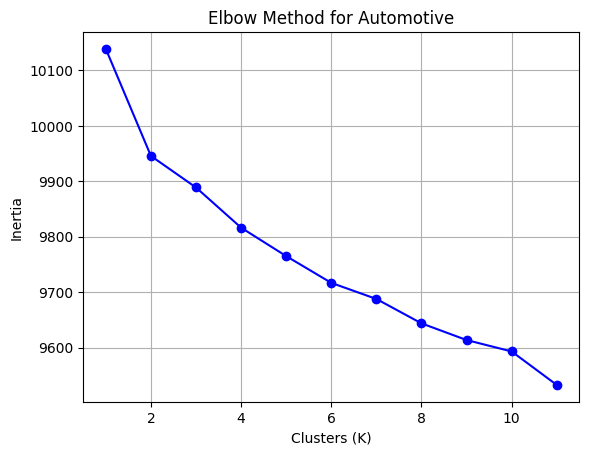

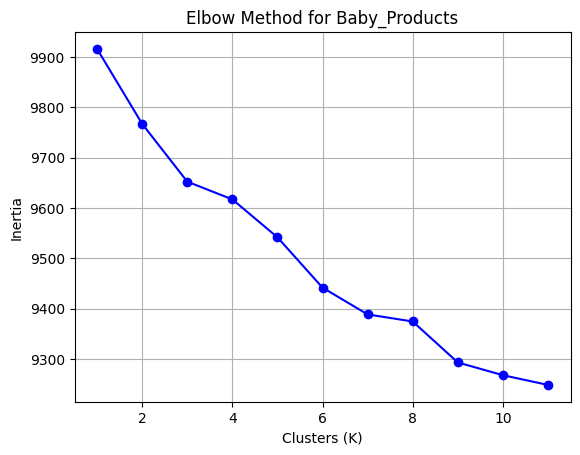

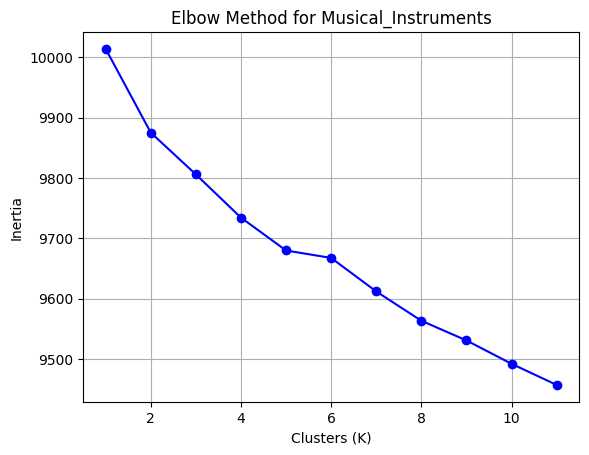

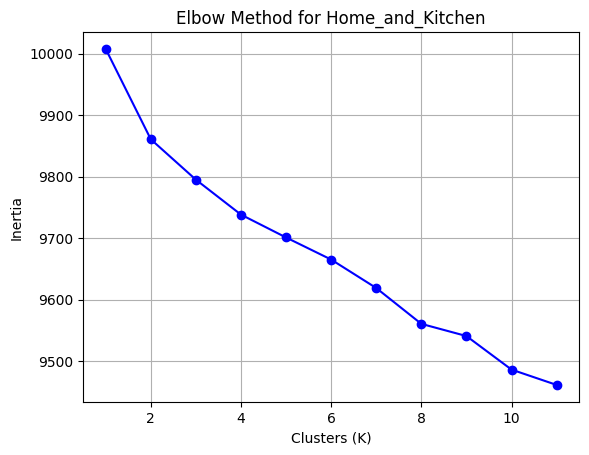

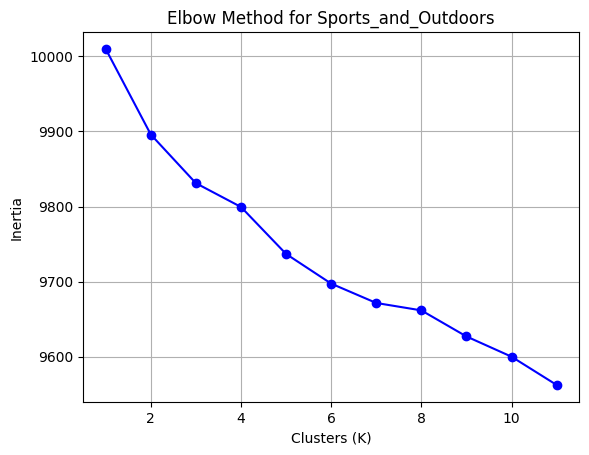

In [ ]:
for category, X in feature_matrices.items():        # Find the best K for each category (using the elbow method).

    inertia = []
    K_range = range(1, 12)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")   # Create the model for k clusters.
        kmeans.fit(X)                    # Fit the model on the feature matrix.
        inertia.append(kmeans.inertia_)  # Calculate and save inertia for each k.

    plt.figure()      # Plot the results to find the optimal K.

    plt.plot(K_range, inertia, 'bo-')
    plt.xlabel("Clusters (K)")
    plt.ylabel("Inertia")
    plt.title(f'Elbow Method for {category}')
    plt.grid(True)
    plt.show()

### Final clustering, silhouette score and PCA visualisation

Silhouette Score for Automotive: 0.010


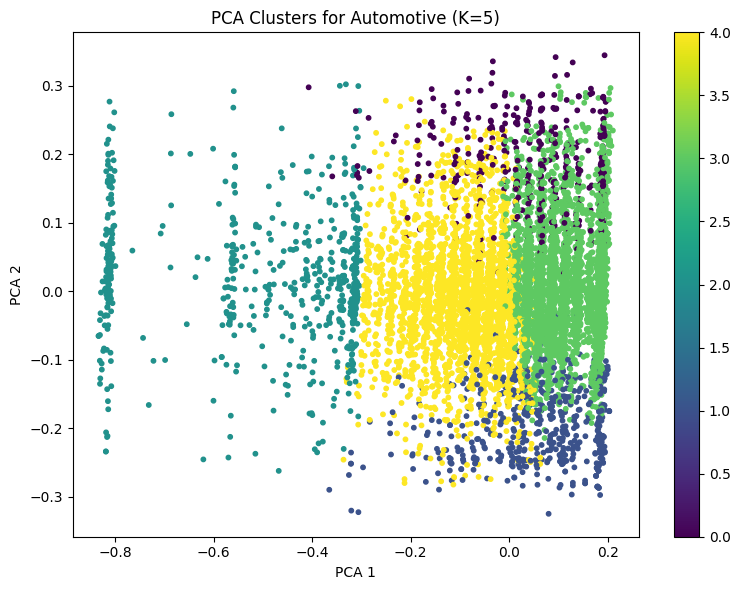

Silhouette Score for Baby_Products: 0.018


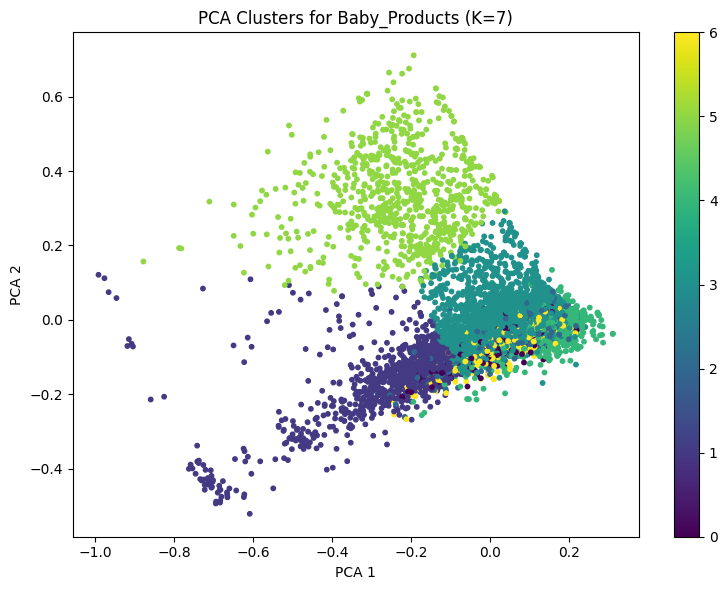

Silhouette Score for Musical_Instruments: 0.008


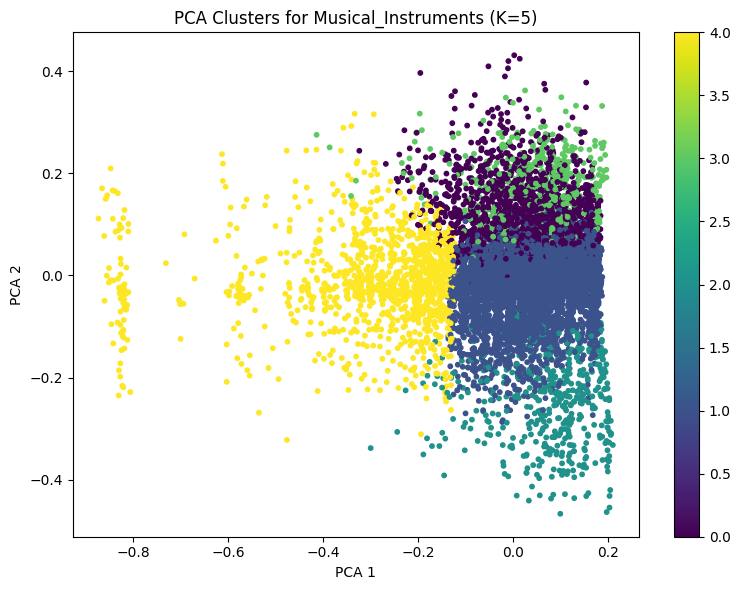

Silhouette Score for Home_and_Kitchen: 0.012


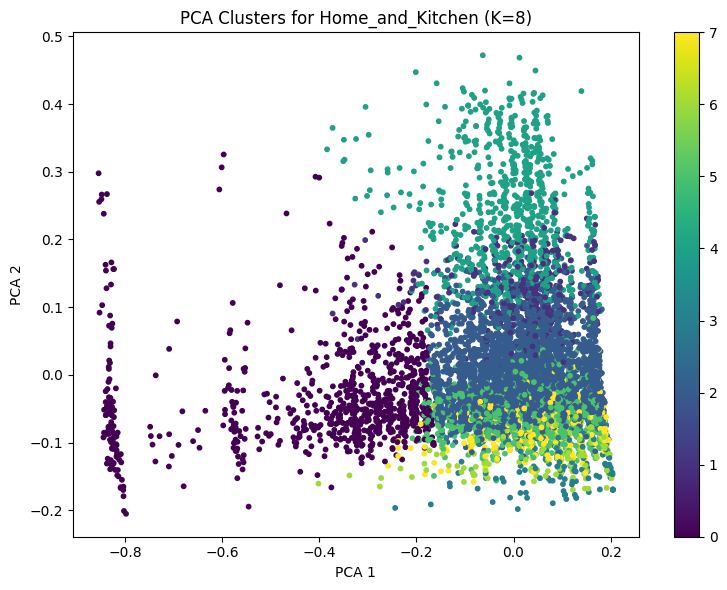

Silhouette Score for Sports_and_Outdoors: 0.009


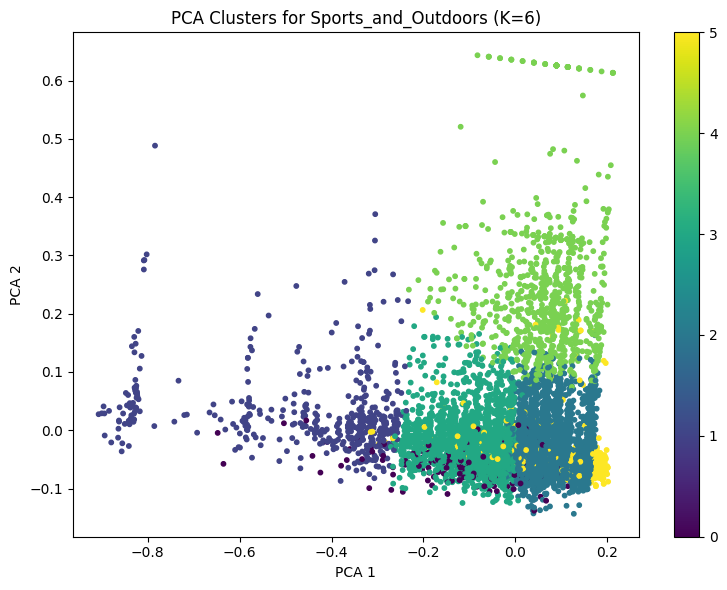

In [ ]:
optimal_k_list = [5, 7, 5, 8, 6]  # Selected k based on the elbow method.
cluster_labels = {}  # Store labels per category
i = 0

for category, X in feature_matrices.items():

    kmeans = KMeans(n_clusters=optimal_k_list[i], random_state=0, n_init="auto")
    labels = kmeans.fit_predict(X)

    sil_score = silhouette_score(X, labels)
    print(f"Silhouette Score for {category}: {sil_score:.3f}")

    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(X.toarray() if hasattr(X, "toarray") else X)   ###

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, s=10)
    plt.title(f"PCA Clusters for {category} (K={optimal_k_list[i]})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

    df = preprocessed_dfs[category]   # Get the category's dataframe and add the cluster column.
    df['cluster'] = labels
    preprocessed_dfs[category] = df
    cluster_labels[category] = labels     # Save labels in the dictionary also.

    i += 1


##Task 2: Recommendation System

Recommenders are built for the **Baby Products** reviews (2,818 reviews) and metadata (3,000 products).
Text, titles and prices were already cleaned/normalised while loading the data.


###Collaborative filtering

In [ ]:
CF_df = reviews_data[['user_id', 'parent_asin', 'rating']]     # Select the fields that CF needs.

####User-Based Collaborative Filtering

In [ ]:
user_item_matrix = CF_df.pivot_table(index='user_id', columns='parent_asin', values='rating').fillna(0)    # Create a user x item matrix.

user_similarity_matrix = cosine_similarity(user_item_matrix)     # Calculate the cosine similarity between users.
user_similarity_df = pd.DataFrame(user_similarity_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)

In [ ]:
# Predict rating using User-Based Collaborative Filtering.
def predict_rating(user_id, item_id, user_item_matrix, user_similarity_df, k=5):

    similar_scores = user_similarity_df.loc[user_id].drop(user_id)  # Get user's similarity scores, excluding themselves.

    users_who_rated = user_item_matrix[user_item_matrix[item_id] >= 1][item_id]   # Users who have rated the item.

    # Keep only the scores for the users who rated the item and select top-k of them.
    similar_scores = similar_scores[similar_scores.index.isin(users_who_rated.index)]
    top_k_users = similar_scores.sort_values(ascending=False).head(k)

    if top_k_users.sum() == 0:
        return np.nan

    top_k_ratings = user_item_matrix.loc[top_k_users.index, item_id]

    # Calculate the weighted average  of ratings from the similar users.
    predicted_rating = (top_k_ratings * top_k_users).sum() / top_k_users.sum()

    return predicted_rating

In [ ]:
# Recommend top K items to a user based on user-based collaborative filtering.
def recommend_top_k(user_id, user_item_matrix, similarity_df, k_sim=5, top_k_items=5):
    if user_id not in user_item_matrix.index:
        return []

    rated_items = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index   # Find which items the user has not rated.
    unrated_items = [item for item in user_item_matrix.columns if item not in rated_items]

    predictions = []              # Predict the user's rating for each unrated item.
    for item in unrated_items:
        pred = predict_rating(user_id, item, user_item_matrix, similarity_df, k=k_sim)
        if not np.isnan(pred):
            predictions.append((item, pred))

    # Top k recommended items.
    top_k = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k_items]
    return top_k

In [ ]:
predicted_matrix = user_item_matrix.copy()

for user in predicted_matrix.index:
    for item in predicted_matrix.columns:
        if predicted_matrix.loc[user, item] == 0.0:
            pred = predict_rating(user, item, user_item_matrix, user_similarity_df, k=5)
            predicted_matrix.loc[user, item] = pred

print(predicted_matrix.head())

parent_asin                   B000066665  B0009MFUZE  B000BNCA4K  B000GB0NZK  \
user_id                                                                        
AE2WMFLNQAV4U5O5XL7AU7LYSL3Q         NaN     5.00000    5.000000         NaN   
AE3A4IYU4JY73JI5QSIKOVYKRV6A    5.000000     3.00000    5.000000    5.000000   
AE3KLVXGZPANXE5XLXYKHTVAZ3FQ    4.821714     5.00000    4.613615    4.609185   
AE47VYS3MSOAIR4FV5SUASWTM5AA         NaN     5.00000    5.000000    5.000000   
AE4IFCYBRA4D7PTJTXLSNL4NHYDA    5.000000     4.50395    5.000000    4.659147   

parent_asin                   B000IDSLOG  B000RHJT6C  B000VEBG26  B001IDYB4Y  \
user_id                                                                        
AE2WMFLNQAV4U5O5XL7AU7LYSL3Q         NaN    4.000000    4.000000         NaN   
AE3A4IYU4JY73JI5QSIKOVYKRV6A         1.0    4.853027    4.499377    5.000000   
AE3KLVXGZPANXE5XLXYKHTVAZ3FQ         5.0    5.000000    4.649063    1.000000   
AE47VYS3MSOAIR4FV5SUASWTM5AA         Na

####Item-Based Collaborative Filtering

In [ ]:
item_user_matrix = user_item_matrix.transpose()

item_similarity_matrix = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity_matrix, index=item_user_matrix.index, columns=item_user_matrix.index)

In [ ]:
def predict_item_rating(user_id, item_id, user_item_matrix, item_similarity_df, k=5):
    if item_id not in item_similarity_df.index or user_id not in user_item_matrix.index:
        return np.nan

    # Get items the user has rated
    user_ratings = user_item_matrix.loc[user_id]
    rated_items = user_ratings[user_ratings > 0]

    # Get similarities between target item and items the user has rated
    similarities = item_similarity_df.loc[item_id, rated_items.index]

    # Select top-K most similar items
    top_k_items = similarities.sort_values(ascending=False).head(k)

    if top_k_items.sum() == 0:
        return np.nan

    top_k_ratings = rated_items[top_k_items.index]

    # Weighted average
    predicted_rating = (top_k_ratings * top_k_items).sum() / top_k_items.sum()
    return predicted_rating

In [ ]:
predicted_matrix2 = item_user_matrix.copy()

for item in predicted_matrix2.index:
    for user in predicted_matrix2.columns:
        if predicted_matrix2.loc[item, user] == 0.0:
            pred = predict_item_rating(user, item, user_item_matrix, item_similarity_df, k=5)
            predicted_matrix2.loc[item, user] = pred

print(predicted_matrix2.head())

user_id      AE2WMFLNQAV4U5O5XL7AU7LYSL3Q  AE3A4IYU4JY73JI5QSIKOVYKRV6A  \
parent_asin                                                               
B000066665                            NaN                      5.000000   
B0009MFUZE                       5.000000                      4.500000   
B000BNCA4K                       3.758578                      4.453014   
B000GB0NZK                            NaN                      3.000000   
B000IDSLOG                            NaN                      5.000000   

user_id      AE3KLVXGZPANXE5XLXYKHTVAZ3FQ  AE47VYS3MSOAIR4FV5SUASWTM5AA  \
parent_asin                                                               
B000066665                       3.524252                           NaN   
B0009MFUZE                       3.744997                       5.00000   
B000BNCA4K                       3.584753                       4.00000   
B000GB0NZK                       2.237333                       4.38793   
B000IDSLOG              

###Content-Based Filtering

In [ ]:
CBF_meta = metadata_data[['price', 'description', 'parent_asin', 'title', 'main_category']]

In [ ]:
# Convert product descriptions into Word2Vec vector (used pre-trained embeddings).
def get_embedding(text, model):

    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.zeros(model.vector_size)

    words = text.lower().split()                    # Tokenize the discription.
    valid_words = [w for w in words if w in model]  # Filter out words not in the model.

    if not valid_words:
        return np.zeros(model.vector_size)

    return np.mean([model[w] for w in valid_words], axis=0)   # Return the element-wise average across all the word vectors.

In [ ]:
#Recommend top-K products with high similarity scores.
def recommend_top_k_products(product_id, similarity_df, top_k=5):

    if product_id not in similarity_df.index:
        return []

    # Get similarity scores for the given product and select top-k of them.
    sims = similarity_df[product_id].drop(product_id)
    top_k_similar = sims.sort_values(ascending=False).head(top_k)

    return list(top_k_similar.items())

In [ ]:
# Calculates an average similarity score of a product to its top-K most similar products.
def predict_product_rating(product_id, similarity_df, top_k=5):
    if product_id not in similarity_df.index:
        return np.nan

    #Get similarity scores of the given product and select top-k of them.
    similarities = similarity_df.loc[product_id].drop(product_id)
    top_k_similarities = similarities.sort_values(ascending=False).head(top_k)

    cbf_score = top_k_similarities.mean() if not top_k_similarities.empty else np.nan  # Compute the average.

    return cbf_score

In [ ]:
CBF_meta = CBF_meta.copy()
CBF_meta['embedding'] = CBF_meta['description'].apply(lambda x: get_embedding(x, w2v_model))

embedding_matrix = np.vstack(CBF_meta['embedding'].values)
content_similarity_matrix = cosine_similarity(embedding_matrix)   # Calculate cosine similarity between product vectors.

product_ids = CBF_meta['parent_asin'].values      # Items x Items dataframe of items similarity.
product_similarity_df = pd.DataFrame(content_similarity_matrix, index=product_ids, columns=product_ids)


product_id = CBF_meta['parent_asin'].iloc[0]  # Pick a product
recommendations = recommend_top_k_products(product_id, product_similarity_df, 5)

print(f"Top Similar Products for: {product_id}")
for asin, score in recommendations:
    print(f"→ {asin} (Similarity: {score:.2f})")


Top Similar Products for: B01DDDXTA8
→ B0BW98ZZ5B (Similarity: 0.95)
→ B083M53PXK (Similarity: 0.95)
→ B09HK57FQL (Similarity: 0.95)
→ B01N78IIYL (Similarity: 0.95)
→ B07H4QPZRJ (Similarity: 0.95)


For every review, the reviewed product is used as a seed and its `K` most similar products are recommended.
Recall@K is the fraction of the user's rated items that appear among these recommendations.
This is an in-sample evaluation (no held-out ratings).

In [ ]:
# Evaluate the recommendations using Recall at K.
def evaluate_recall_at_k(reviews_data, similarity_df, k=5):

    hits = 0
    total = 0

    for _, row in reviews_data.iterrows():
        product_id = row['parent_asin']
        user_id = row['user_id']

        # Skip if product or user missing.
        if product_id not in similarity_df.index or user_id not in user_item_matrix.index:
            continue

        # Ground truth are the items the user has rated.
        user_rated_items = user_item_matrix.loc[user_id]
        ground_truth_items = set(user_rated_items[user_rated_items > 0].index)

        # Recommended products for this product.
        recommended_items = recommend_top_k_products(product_id, similarity_df, top_k=k)
        recommended_ids = {asin for asin, _ in recommended_items}


        hits += len(ground_truth_items.intersection(recommended_ids))   # Count
        total += len(ground_truth_items)

    if total == 0:
        return 0.0
    return hits / total

In [ ]:
# Run evaluation (top-15).
recall_at_15 = evaluate_recall_at_k(reviews_data, product_similarity_df, k=15)
print(f"Recall at 15 (CBF): {recall_at_15:.4f}")

Recall at 15 (CBF): 0.0144


### Hybrid approach: weighted average

The final score of an item is a weighted average of the three methods (user-based CF, item-based CF, content-based).
If a method cannot produce a score (NaN), it is skipped and the remaining weights are re-normalised.
Default weights: 0.4 / 0.3 / 0.3.

In [ ]:
def hybrid_predict_rating(user_id, item_id, user_item_matrix, user_similarity_df, item_similarity_df, product_similarity_df, w=[0.4, 0.3, 0.3], k=5):
    # Assigns weights to each method
    w_user_cf, w_item_cf, w_cbf = w

    # Get each score.
    user_score = predict_rating(user_id, item_id, user_item_matrix, user_similarity_df, k)
    item_score = predict_item_rating(user_id, item_id, user_item_matrix, item_similarity_df, k)
    cbf_score = predict_product_rating(item_id, product_similarity_df, k)

    final_score = 0.0
    total_weight = 0.0

    # Add each score.
    if not np.isnan(user_score):
        final_score += w_user_cf * user_score
        total_weight += w_user_cf

    if not np.isnan(item_score):
        final_score += w_item_cf * item_score
        total_weight += w_item_cf

    if not np.isnan(cbf_score):
        final_score += w_cbf * cbf_score
        total_weight += w_cbf

    # print(f"[DEBUG] User: {user_id}, Item: {item_id}, "
    #   f"User_CF: {user_score}, Item_CF: {item_score}, CBF: {cbf_score}, "
    #   f"Final: {final_score / total_weight if total_weight > 0 else 'NaN'}")

    return final_score / total_weight if total_weight > 0 else np.nan

In [ ]:
def recommend_top_k_hybrid(user_id, user_item_matrix, all_items, user_similarity_df, item_similarity_df, product_similarity_df, top_k_items=5, k=5):

    if user_id not in user_item_matrix.index:
        return []

    rated_items = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index
    unrated_items = [item for item in all_items if item not in rated_items]

    predictions = []
    for item in unrated_items:
        score = hybrid_predict_rating(user_id, item, user_item_matrix, user_similarity_df, item_similarity_df, product_similarity_df, k=k)
        if not np.isnan(score):
            predictions.append((item, score))

    top_k = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k_items]
    return top_k

In [ ]:
user_id = 'AE3KLVXGZPANXE5XLXYKHTVAZ3FQ'
all_items = user_item_matrix.columns.tolist()

top_hybrid_recs = recommend_top_k_hybrid(user_id, user_item_matrix, all_items, user_similarity_df, item_similarity_df, product_similarity_df, k=5)

print(f"Top Hybrid Recommendations for User {user_id}:")
for asin, score in top_hybrid_recs:
    print(f"→ {asin} (Hybrid Score: {score:.2f})")

Top Hybrid Recommendations for User AE3KLVXGZPANXE5XLXYKHTVAZ3FQ:
→ B00394DQGE (Hybrid Score: 5.00)
→ B00QQA23KI (Hybrid Score: 5.00)
→ B01BOGG4I0 (Hybrid Score: 5.00)
→ B08DPRM9TF (Hybrid Score: 5.00)
→ B09SC1ZWXZ (Hybrid Score: 5.00)


##Task3: Classification task - sentiment analysis

Goal: predict the sentiment class of a review from its text. Labels are derived from the star rating:
**positive** (4–5 stars), **neutral** (3 stars), **negative** (1–2 stars).

###Preprocessing

**Text and title cleaning done during loading.**

In [ ]:
reviews_temp = reviews_data.copy()

### Feature extraction

Two text representations are compared:

* **TF-IDF** (up to 10,000 terms).
* **Averaged pre-trained word embeddings** (100-d GloVe vectors, labelled "Word2Vec" in the code and results).

In [ ]:
# Transform the 'text' column into a TF-IDF matrix.
tf_idf_vectorizer = TfidfVectorizer(max_features=10000, min_df=10, max_df=0.7)
tf_idf_matrix = tf_idf_vectorizer.fit_transform(reviews_temp['text'])

# For each review convert the text to a Word2Vec embedding.
w2v_features = np.array([get_embedding(text, w2v_model) for text in reviews_temp['text']])

### Model comparison

Three classifiers (Naive Bayes, KNN, Random Forest) are trained on both feature sets using an 80/20 train/test split.
Weighted F1 on the test set gives a quick first comparison.

In [ ]:
def map_rating_to_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

reviews_temp["sentiment"] = reviews_temp["rating"].apply(map_rating_to_sentiment)

y = reviews_temp["sentiment"]  # True labels.

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(    # Split to training and test sets.
    tf_idf_matrix, y, test_size=0.2, random_state=42)

X_train_w2v, X_test_w2v, _, _ = train_test_split(
    w2v_features, y, test_size=0.2, random_state=42)


models = {
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

feature_sets = {
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2Vec": (X_train_w2v, X_test_w2v)
}

results = []

for model_name, model in models.items():
    for feature_set_name, (X_train, X_test) in feature_sets.items():

        if model_name == "Naive Bayes" and feature_set_name == "Word2Vec":
            model = GaussianNB()   # Can't use MultinomialNB because it needs not-negative inputs.

        model.fit(X_train, y_train)      # Train the model and
        y_pred = model.predict(X_test)   # predict sentiments in the test set data.

        f1 = f1_score(y_test, y_pred, average='weighted')   # Evaluate via f1_score.

        results.append({
            "Model": model_name,
            "Feature Set": feature_set_name,
            "F1-Score": f1
        })

results_df = pd.DataFrame(results)
print(results_df)

           Model Feature Set  F1-Score
0    Naive Bayes      TF-IDF  0.800214
1    Naive Bayes    Word2Vec  0.501978
2            KNN      TF-IDF  0.804438
3            KNN    Word2Vec  0.824118
4  Random Forest      TF-IDF  0.819409
5  Random Forest    Word2Vec  0.811681


### 10-fold cross-validation (training set)

Macro-averaged precision, recall and F1 treat the three classes equally, which matters because the classes are imbalanced.

In [ ]:
evaluation_metrics = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, average='macro', zero_division=0),
    "Recall": make_scorer(recall_score, average='macro', zero_division=0),
    "F1-Score": make_scorer(f1_score, average='macro', zero_division=0)
}


Cross_Validation_results = []   # Store results.

for feature_set_name, (X_train, X_test) in feature_sets.items():
    for model_name, model in models.items():

        if model_name == "Naive Bayes" and feature_set_name == "Word2Vec":
            model = GaussianNB()     # Can't use MultinomialNB because it needs not-negative inputs.

        # 10-fold cross-validation on the training data
        scores = cross_validate(model, X_train, y_train, cv=10, scoring=evaluation_metrics)

        Cross_Validation_results.append({     # Save the mean scores of each metric.
            "Model": model_name,
            "Feature Set": feature_set_name,
            "Accuracy": scores["test_Accuracy"].mean(),
            "Precision": scores["test_Precision"].mean(),
            "Recall": scores["test_Recall"].mean(),
            "F1-Score": scores["test_F1-Score"].mean()
        })

Cross_Validation_results_df = pd.DataFrame(Cross_Validation_results)

In [ ]:
Cross_Validation_results_df = Cross_Validation_results_df[
    ["Feature Set", "Model", "Precision", "Recall", "F1-Score", "Accuracy"]
]

# Display the results.
print("\nCross-Validation Results on train set :\n")
print(tabulate(Cross_Validation_results_df, headers='keys', showindex=False, tablefmt='psql'))


Cross-Validation Results on train set :

+---------------+---------------+-------------+----------+------------+------------+
| Feature Set   | Model         |   Precision |   Recall |   F1-Score |   Accuracy |
|---------------+---------------+-------------+----------+------------+------------|
| TF-IDF        | Naive Bayes   |    0.289708 | 0.333333 |   0.309993 |   0.869125 |
| TF-IDF        | KNN           |    0.289649 | 0.332821 |   0.309737 |   0.867792 |
| TF-IDF        | Random Forest |    0.506127 | 0.356713 |   0.354173 |   0.869123 |
| Word2Vec      | Naive Bayes   |    0.382584 | 0.425126 |   0.293173 |   0.410389 |
| Word2Vec      | KNN           |    0.462649 | 0.352519 |   0.349836 |   0.860696 |
| Word2Vec      | Random Forest |    0.356871 | 0.339412 |   0.321532 |   0.87001  |
+---------------+---------------+-------------+----------+------------+------------+


### Final evaluation on the held-out test set

In [ ]:
test_set_results = []      # Store results.

for feature_set_name, (X_train, X_test) in feature_sets.items():
    for model_name, model in models.items():

        if model_name == "Naive Bayes" and feature_set_name == "Word2Vec":
            model = GaussianNB()     # Can't use MultinomialNB because it needs not-negative inputs.

        model.fit(X_train, y_train) # Train the model.

        y_pred = model.predict(X_test)     # Make predictions in the test set data.

        # Compute evaluation metrics.
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        test_set_results.append({        # Save the scores of each metric.
            "Model": model_name,
            "Feature Set": feature_set_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

test_set_results_df = pd.DataFrame(test_set_results)

In [ ]:
test_set_results_df = test_set_results_df[
    ["Feature Set", "Model", "Precision", "Recall", "F1-Score", "Accuracy"]
]

# Display the results.
print("\Evaluation on test set  :\n")
print(tabulate(test_set_results_df, headers='keys', showindex=False, tablefmt='psql'))

\Evaluation on test set  :

+---------------+---------------+-------------+----------+------------+------------+
| Feature Set   | Model         |   Precision |   Recall |   F1-Score |   Accuracy |
|---------------+---------------+-------------+----------+------------+------------|
| TF-IDF        | Naive Bayes   |    0.287825 | 0.333333 |   0.308912 |   0.863475 |
| TF-IDF        | KNN           |    0.62167  | 0.341463 |   0.325079 |   0.865248 |
| TF-IDF        | Random Forest |    0.542727 | 0.374633 |   0.385341 |   0.865248 |
| Word2Vec      | Naive Bayes   |    0.373994 | 0.402906 |   0.290658 |   0.406028 |
| Word2Vec      | KNN           |    0.612014 | 0.396286 |   0.418818 |   0.863475 |
| Word2Vec      | Random Forest |    0.844841 | 0.358168 |   0.357777 |   0.867021 |
+---------------+---------------+-------------+----------+------------+------------+


Accuracy (≈0.86 for most models) is much higher than the macro-averaged F1 (≈0.3–0.4). The classes are strongly
imbalanced: most reviews belong to one class, so a classifier can score high accuracy by predicting mostly that class.
Naive Bayes on TF-IDF, for example, has a macro recall of exactly 1/3, i.e. it predicts a single class. The macro-averaged
metrics are therefore the more informative ones here.